# Transfer entropy analysis

In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

import pyaldata as pyal
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pyinform

from sklearn.linear_model import LinearRegression

import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt


## First attempt

In [2]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M061_2025_03_06_14_00',
    combine_time_bins=True
)
df_ = handler.df

field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to int.
array field all_KSLabel could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field GPe_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field GPe_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.


/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/

Combined every 3 bins
Resulting all_spikes ephys data shape is (NxT): (11, 20000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 20000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 20000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 20000)
Resulting CP_spikes ephys data shape is (NxT): (172, 20000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 20000)


In [3]:
df = dt.add_pca_df(df_, n_components=None)
df = dt.add_bhv(df)
df_tr = pyal.select_trials(df, df.trial_name == 'trial')
perturb_td = pyal.restrict_to_interval(df_tr, 'idx_sol_on', rel_start = -4, rel_end=33)

In [ ]:
def get_te_from_df(trial_data, signal_x, signal_y, k=1, n_bins=5):
    x = np.concatenate(trial_data[f'{signal_x}'].values)[:, 40]
    y = np.concatenate(trial_data[f'{signal_y}'].values)[:, 40]

    bins_x = np.linspace(np.min(x), np.max(x), n_bins + 1)
    bins_y = np.linspace(np.min(y), np.max(y), n_bins + 1)

    x_discretized, y_discretized = np.digitize(x, bins_x), np.digitize(y, bins_y)

    return pyinform.transfer_entropy(x_discretized, y_discretized, k=k)


def get_trial_based_te_from_td(trial_data, signal_x, signal_y, k=1, n_bins=5):
    x = np.stack(trial_data[f'{signal_x}'].values)
    y = np.stack(trial_data[f'{signal_y}'].values)

    bins_x = np.linspace(np.min(x), np.max(x), n_bins + 1)
    bins_y = np.linspace(np.min(y), np.max(y), n_bins + 1)

    x_discretized, y_discretized = np.digitize(x, bins_x), np.digitize(y, bins_y)



    return pyinform.transfer_entropy(x_discretized, y_discretized, k=k)

In [24]:
te_mop_cp = get_te_from_df(
    perturb_td,
    signal_x='MOp_rates',
    signal_y='VAL_rates',
    k=2
)
te_cp_mop = get_te_from_df(
    perturb_td,
    signal_x='VAL_rates',
    signal_y='MOp_rates',
    k=2
)

print(f'MOp -> VAL: {te_mop_cp}')
print(f'VAL -> MOp {te_cp_mop}')

MOp -> VAL: 0.1698415073142966
VAL -> MOp 0.09593528922870906


In [23]:
te_mop_cp = get_te_from_df(
    perturb_td,
    signal_x='VAL_rates',
    signal_y='CP_rates',
    k=3
)
te_cp_mop = get_te_from_df(
    perturb_td,
    signal_x='CP_rates',
    signal_y='VAL_rates',
    k=3
)

print(f'VAL -> CP {te_mop_cp}')
print(f'CP -> VAL {te_cp_mop}')

VAL -> CP 0.24030393796237154
CP -> VAL 0.39502221402894055


---
Discretizing signals

In [5]:
k = 1
n_bins = 50

te_mop_cp = get_te_from_df(
    pyal.select_trials(df, df.trial_name == 'intertrial'),
    signal_x='MOp_rates_pca',
    signal_y='CP_rates_pca',
    k=k,
    n_bins=n_bins
)
te_cp_mop = get_te_from_df(
    pyal.select_trials(df, df.trial_name == 'intertrial'),
    signal_x='CP_rates_pca',
    signal_y='MOp_rates_pca',
    k=k,
    n_bins=n_bins
)

print(f'MOp -> CP: {te_mop_cp}')
print(f'CP -> MOp {te_cp_mop}')

MOp -> CP: 0.13376999242703272
CP -> MOp 0.19384227787413869


In [9]:
k = 1
n_bins = 50

te_mop_cp = get_te_from_df(
    perturb_td,
    signal_x='MOp_rates_pca',
    signal_y='CP_rates_pca',
    k=k,
    n_bins=n_bins
)
te_cp_mop = get_te_from_df(
    perturb_td,
    signal_x='CP_rates_pca',
    signal_y='MOp_rates_pca',
    k=k,
    n_bins=n_bins
)

print(f'MOp -> CP: {te_mop_cp}')
print(f'CP -> MOp {te_cp_mop}')

MOp -> CP: 0.41426594511196807
CP -> MOp 0.518790861021536


In [7]:
k = 1
n_bins = 50

te_mop_cp = get_te_from_df(
    perturb_td,
    signal_x='VAL_rates_pca',
    signal_y='CP_rates_pca',
    k=k,
    n_bins=n_bins
)
te_cp_mop = get_te_from_df(
    perturb_td,
    signal_x='CP_rates_pca',
    signal_y='VAL_rates_pca',
    k=k,
    n_bins=n_bins
)

print(f'VAL -> CP: {te_mop_cp}')
print(f'CP -> VAL {te_cp_mop}')

VAL -> CP: 0.3447838307957438
CP -> VAL 0.41909198945306886


In [84]:
te_mop_cp = get_te_from_df(
    perturb_td,
    signal_x='VAL_rates_pca',
    signal_y='MOp_rates_pca',
    k=1
)
te_cp_mop = get_te_from_df(
    perturb_td,
    signal_x='MOp_rates_pca',
    signal_y='VAL_rates_pca',
    k=1
)

print(f'VAL -> MOp: {te_mop_cp}')
print(f'MOp -> VAL {te_cp_mop}')

VAL -> MOp: 0.02033463015088035
MOp -> VAL 0.012392314270635914


In [50]:
te_mop_cp

0.0681108628971594

In [15]:
concat_signal_x = np.concatenate(perturb_td[f'MOp_rates_pca'].values[:, 0])

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [16]:
import numpy as np
import pyinform
import matplotlib.pyplot as plt

# Simulate firing rate data (e.g., neural signals)
np.random.seed(42)
n_samples = 1000
X = np.random.normal(loc=5, scale=2, size=n_samples)  # Continuous firing rates for X
Y = np.roll(X, 1)  # Y is a delayed version of X (simulating a causal relationship)

# Discretize the firing rates using uniform binning (e.g., 5 bins)
n_bins = 5
bin_edges = np.linspace(np.min(X), np.max(X), n_bins + 1)
X_discretized = np.digitize(X, bin_edges) - 1  # Subtract 1 to make the bins 0-indexed
Y_discretized = np.digitize(Y, bin_edges) - 1

# Calculate Transfer Entropy (from X to Y)
te_x_to_y = pyinform.transfer_entropy(X_discretized, Y_discretized, k=1)

# Calculate Transfer Entropy (from Y to X)
te_y_to_x = pyinform.transfer_entropy(Y_discretized, X_discretized, k=1)

print(f"Transfer Entropy from X to Y: {te_x_to_y}")
print(f"Transfer Entropy from Y to X: {te_y_to_x}")


Transfer Entropy from X to Y: 1.6271247394502864
Transfer Entropy from Y to X: 0.045324577565409536


In [25]:
bin_edges

array([-1.48253468,  1.35506485,  4.19266438,  7.03026392,  9.86786345,
       12.70546298])

In [26]:
X_discretized

array([2, 2, 2, 3, 2, 2, 3, 2, 1, 2, 1, 1, 2, 0, 1, 1, 1, 2, 1, 1, 3, 2,
       2, 1, 1, 2, 1, 2, 1, 2, 1, 3, 2, 1, 2, 1, 2, 0, 1, 2, 2, 2, 2, 2,
       1, 1, 1, 3, 2, 1, 2, 2, 1, 2, 3, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 3,
       2, 2, 2, 1, 2, 3, 2, 3, 0, 2, 2, 2, 2, 0, 2, 2, 3, 1, 1, 1, 2, 2,
       1, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 2, 1, 1, 2, 1, 2, 2, 3, 2, 2, 2,
       0, 2, 2, 4, 2, 2, 2, 1, 3, 2, 2, 1, 3, 1, 2, 3, 1, 1, 2, 1, 1, 2,
       1, 2, 1, 3, 1, 2, 2, 1, 2, 3, 1, 2, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2,
       2, 1, 3, 2, 1, 2, 1, 2, 3, 1, 2, 2, 2, 3, 2, 1, 1, 1, 2, 2, 2, 2,
       2, 3, 2, 4, 2, 1, 1, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 1, 2, 2, 1, 2,
       2, 1, 2, 2, 3, 3, 1, 1, 2, 2, 2, 5, 2, 3, 2, 2, 2, 2, 1, 2, 1, 2,
       3, 0, 2, 1, 1, 3, 2, 1, 1, 2, 1, 2, 2, 1, 3, 2, 0, 2, 1, 2, 1, 2,
       2, 2, 1, 2, 1, 1, 3, 2, 1, 2, 3, 3, 1, 1, 3, 1, 2, 2, 1, 2, 0, 1,
       2, 1, 3, 1, 1, 2, 3, 1, 3, 2, 1, 2, 2, 1, 2, 2, 2, 2, 3, 1, 3, 0,
       2, 2, 2, 1, 2, 1, 1, 2, 2, 1, 2, 2, 2, 2, 1,

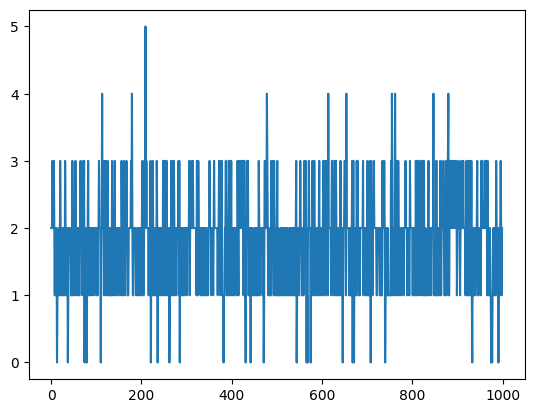

In [19]:
plt.plot(X_discretized)

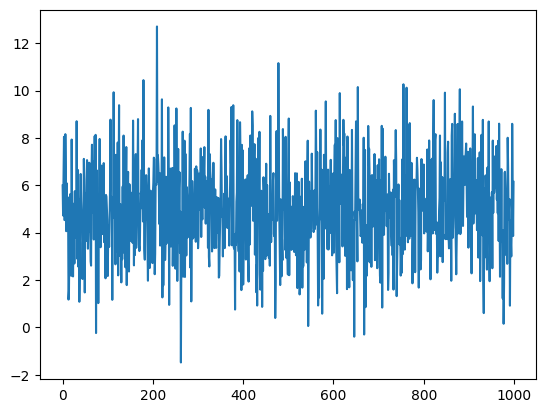

In [18]:
plt.plot(X)

/tmp/ipykernel_3772461/2343069461.py:24: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X, shade=True, label='X KDE')
/tmp/ipykernel_3772461/2343069461.py:25: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(Y, shade=True, label='Y KDE')


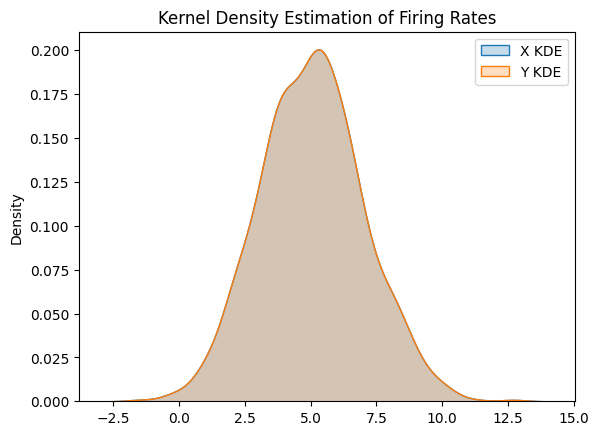

In [20]:
import numpy as np
import seaborn as sns
from sklearn.neighbors import KernelDensity
import matplotlib.pyplot as plt

# Simulate firing rate data (e.g., neural signals)
np.random.seed(42)
n_samples = 1000
X = np.random.normal(loc=5, scale=2, size=n_samples)  # Continuous firing rates for X
Y = np.roll(X, 1)  # Y is a delayed version of X

# Fit Kernel Density Estimation (KDE) for X and Y
kde_x = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(X[:, np.newaxis])
kde_y = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(Y[:, np.newaxis])

# Evaluate log densities
log_dens_X = kde_x.score_samples(X[:, np.newaxis])
log_dens_Y = kde_y.score_samples(Y[:, np.newaxis])

# Compute joint probability density (for simplicity, assuming independence here)
joint_log_dens = log_dens_X + log_dens_Y

# Plot the estimated density for X and Y
sns.kdeplot(X, shade=True, label='X KDE')
sns.kdeplot(Y, shade=True, label='Y KDE')
plt.title('Kernel Density Estimation of Firing Rates')
plt.legend()
plt.show()

# You would need to implement or use custom methods to compute Transfer Entropy using KDE


In [31]:
x = np.array([0.2, 6.4, 3.0, 1.6, 10, 11, 0.3])

bins = np.array([0.0, 1.0, 2.5, 4.0, 10.0])

inds = np.digitize(x, bins)
inds

array([1, 4, 3, 2, 5, 5, 1])